# 07 - When the world shifts: covariate shift and weighted conformal

> "We are launching in Eastvale next quarter. The model was trained on Riverton. Do your
> 90% intervals still hold?" — the acquisitions desk, planning the expansion

The sharper statistical question: the coverage guarantee we built in notebooks 02 and 03
rests on exactly one assumption — that tomorrow's listing could be shuffled in with the
calibration listings and nobody could tell (exchangeability). An expansion into a new
market is a deliberate, announced violation of that assumption. So the real questions are:
how badly does the guarantee degrade when the market mix changes, how would we even notice,
and — when we know *what* changed — can we repair the guarantee without collecting a single
labeled sale in the new market?

**What you will learn**

- How a market expansion silently voids the 90% guarantee — no error, no warning, coverage
  just rots.
- The difference between covariate shift and concept drift, and why only one of them is
  repairable by reweighting.
- The classifier trick: your shift *detector* is your correction *factor* (a logistic
  regression estimates the likelihood ratio).
- The weighted corrected quantile that restores coverage, and its price: a shrunken
  effective sample size, wider intervals, sometimes infinite ones.

Where we are in the series: notebook 06 squeezed guarantees out of small data; this
notebook repairs the guarantee when the world changes; notebook 08 ships everything with
MAPIE on real data.

## 1. The eastvale launch

This is the most intermediate notebook in the series, and you already own every
ingredient. Nonconformity scores and the corrected quantile came from notebook 02. The
leaderboard argument — the test listing is equally likely to land at any rank among the
calibration scores, and that single symmetry *is* the coverage guarantee — came from
notebook 03. Everything in this notebook is those three ideas, re-run in a world where the
symmetry has been deliberately broken and then carefully restored.

The story: Hearthstone's instant-offer model was trained and calibrated in Riverton, its
home market. The desk validated the 90% intervals there, the dashboards are green, and the
company is expanding into Eastvale — a newer suburb where the homes coming to market are
systematically bigger, newer, and farther from the center. Same country, same buyers, same
appraisal physics. Different mix of homes.

We simulate the launch: train on 3,000 Riverton sales, calibrate on 1,500 more, then face
2,000 incoming Eastvale listings (plus a 2,000-listing Riverton holdout as the control
group — the world the desk *thinks* it is operating in).

In [1]:
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
RANDOM_SEED = 20260707

# Series palette: blue = data, green = good, amber = calibration,
# red = bad/naive, gray = reference, purple = alternative method.
BLUE, GREEN, AMBER, RED, GRAY, PURPLE = (
    "#2563EB", "#059669", "#F59E0B", "#DC2626", "#6B7280", "#7C3AED",
)

In [2]:
FEATURE_NAMES = ["size_m2", "age_years", "dist_center_km", "condition_1to5"]

def simulate_hearthstone_listings(n, seed, region="riverton"):
    """Simulate n home listings for Hearthstone, our property-tech startup.

    What the simulator bakes in (and what we will test against later):
    - Price depends nonlinearly on size, age, distance to the center, and condition.
    - Noise is larger for bigger homes: two 60 m2 flats sell for nearly the same
      price, two 300 m2 villas do not. This heteroskedasticity is deliberate.
    - 'riverton' and 'eastvale' differ ONLY in the mix of homes on the market
      (newer, bigger, farther out in eastvale), NOT in how features map to price.
      In the language of notebook 07: pure covariate shift, identical P(price | features).

    Returns X (n x 4 array: size_m2, age_years, dist_center_km, condition_1to5)
    and y (price in thousands of dollars).
    """
    rng = np.random.default_rng(seed)
    if region == "riverton":
        size = rng.gamma(shape=6.0, scale=20.0, size=n) + 30.0
        age = rng.uniform(0.0, 60.0, size=n)
        dist = rng.exponential(scale=6.0, size=n)
    elif region == "eastvale":
        size = rng.gamma(shape=9.0, scale=24.0, size=n) + 40.0
        age = rng.uniform(0.0, 25.0, size=n)
        dist = rng.exponential(scale=12.0, size=n)
    else:
        raise ValueError(f"Unknown region: {region}")
    condition = rng.integers(1, 6, size=n).astype(float)
    log_price = (
        10.0
        + 0.70 * np.log(size)
        - 0.004 * age
        - 0.035 * dist
        + 0.05 * condition
    )
    noise_sd = 0.10 + 0.0008 * size  # bigger homes, noisier prices - on purpose
    log_price = log_price + rng.normal(0.0, noise_sd)
    X = np.column_stack([size, age, dist, condition])
    return X, np.exp(log_price) / 1000.0

Read the docstring before the code that uses it, because it states the single most
important fact of this notebook: the two regions differ *only* in which homes come to
market — the `size`, `age` and `dist` draws — while the formula mapping features to
`log_price` is line-for-line identical. A 250 m2, 10-year-old home 12 km out is priced by
the same rule in both regions; Eastvale just has far more of them.

That situation has a name. **Covariate shift** means the distribution of inputs changes
between calibration and deployment while the relationship between inputs and outputs,
P(y | x), stays exactly the same. Its dangerous cousin, **concept drift**, is when
P(y | x) itself moves — the same house now sells for a different price. The distinction
decides whether anything in this notebook can help you (field guide §10):

| Term | Plain-English meaning | Hearthstone example | Can weighted conformal repair it? |
|---|---|---|---|
| Covariate shift | Different homes come to market; each home is still priced by the old rule | The Eastvale launch: bigger, newer, farther homes | Yes — that is this notebook |
| Concept drift | The pricing rule itself changed | A new property tax rewrites what every home fetches | No — old scores describe a dead world; collect new data and retrain |

One caution before we simulate: in real life nobody hands you the docstring. "Is this
shift or drift?" is a judgment call you must defend in writing — we return to that in
section 8.

In [3]:
# One dataset per role, each with its own seed so any cell can be re-run alone.
X_train, y_train = simulate_hearthstone_listings(3000, seed=RANDOM_SEED, region="riverton")
X_calib, y_calib = simulate_hearthstone_listings(1500, seed=RANDOM_SEED + 1, region="riverton")
X_river, y_river = simulate_hearthstone_listings(2000, seed=RANDOM_SEED + 2, region="riverton")
X_east, y_east = simulate_hearthstone_listings(2000, seed=RANDOM_SEED + 3, region="eastvale")

print(f"train (riverton):      {X_train.shape[0]} listings")
print(f"calibration (riverton): {X_calib.shape[0]} listings")
print(f"holdout (riverton):     {X_river.shape[0]} listings")
print(f"incoming (eastvale):    {X_east.shape[0]} listings  <- prices unknown on launch day")

summary = pd.DataFrame(
    {
        "riverton_calibration_mean": X_calib.mean(axis=0),
        "eastvale_incoming_mean": X_east.mean(axis=0),
    },
    index=FEATURE_NAMES,
)
summary.round(1)

train (riverton):      3000 listings
calibration (riverton): 1500 listings
holdout (riverton):     2000 listings
incoming (eastvale):    2000 listings  <- prices unknown on launch day


,riverton_calibration_mean,eastvale_incoming_mean
size_m2,150.5,258.2
age_years,30.1,12.5
dist_center_km,5.9,12.0
condition_1to5,3.0,3.0


The feature means tell the whole expansion story in three lines. The average Eastvale
listing is 258.2 m2 against Riverton's 150.5, is 12.5 years old against 30.1, and sits
12.0 km from the center against 5.9. `condition_1to5` is untouched (3.0 in both) — the
simulator draws it identically in each region. Note what these numbers do *not* say: they
say nothing about prices, and nothing about whether the model is wrong. Every one of these
Eastvale homes is still priced by the exact rule the model learned. The inputs moved; the
input-to-output map did not.

Note also that this table needed no Eastvale price labels — just the incoming listings'
features, which the desk has on day one. Keep that in mind for section 5.

## 2. Watch the guarantee rot silently

Here is notebook 02's fifteen-line recipe, unchanged: fit the model on training data,
compute nonconformity scores — absolute residuals, |actual price − predicted price| — on
the untouched calibration set, take the corrected quantile `q_hat`, and promise that
`prediction ± q_hat` traps the true price 90% of the time. The promise was audited in
notebook 03 and it held. Now we run it into the launch, scoring both test sets with the
same `q_hat`: the Riverton holdout (business as usual) and the Eastvale listings
(the expansion).

In [4]:
alpha = 0.10  # 10% error budget -> 90% target coverage, the series default

model = GradientBoostingRegressor(random_state=RANDOM_SEED)
model.fit(X_train, y_train)

# Nonconformity scores on the calibration set - never on training residuals
# (field guide S2: training residuals are optimistically small).
scores = np.abs(y_calib - model.predict(X_calib))
n = len(scores)

# The corrected quantile: ceil((n+1)(1-alpha))/n, NOT the plain (1-alpha) quantile.
q_level = math.ceil((n + 1) * (1 - alpha)) / n
assert q_level <= 1.0, "Calibration set too small for this alpha - the honest interval is infinite (field guide S1)"
q_hat = np.quantile(scores, q_level, method="higher")

pred_river = model.predict(X_river)
pred_east = model.predict(X_east)
cov_river = np.mean(np.abs(y_river - pred_river) <= q_hat)
cov_east = np.mean(np.abs(y_east - pred_east) <= q_hat)

print(f"corrected quantile level {q_level:.4f} of {n} scores -> q_hat = {q_hat:.1f} thousand dollars")
print(f"interval recipe: predicted price +/- {q_hat:.1f}  (width {2 * q_hat:.1f})")
print(f"coverage on riverton holdout (n={len(y_river)}): {cov_river:.3f}   <- the world the desk validated in")
print(f"coverage on eastvale launch  (n={len(y_east)}): {cov_east:.3f}   <- the world the desk is entering")

corrected quantile level 0.9007 of 1500 scores -> q_hat = 268.5 thousand dollars
interval recipe: predicted price +/- 268.5  (width 537.0)
coverage on riverton holdout (n=2000): 0.911   <- the world the desk validated in
coverage on eastvale launch  (n=2000): 0.687   <- the world the desk is entering


On the Riverton holdout, coverage lands at 0.911 — the promise kept. With 2,000 test
listings, Monte Carlo noise around a true 0.90 is about ±0.013 (two standard errors of
the empirical coverage), so anything between roughly 0.887 and 0.913 is the guarantee
working. On Eastvale, the *same intervals from
the same code* cover 0.687. The desk promised nine offers in ten inside the band; it will
deliver about two in three.

Two things make this the most dangerous failure mode in the series. First, the magnitude:
Tibshirani, Barber, Candès and Ramdas (2019) — the paper this notebook retells — induced a
covariate shift on a real NASA airfoil dataset and watched split conformal fall from 90.2%
to 82.2% coverage. That was the real-data twin of our demo; our expansion is harsher and
costs 22 points instead of 8. Second, the silence: nothing raised an exception. The model
happily prices Eastvale homes, `q_hat` is still a perfectly valid quantile of Riverton
scores, every dashboard metric computed on Riverton data stays green. Coverage on the new
market is not a number anyone sees until Eastvale sales start closing — months of
mispriced offers later. Exchangeability is the load-bearing wall, and it fails without a
sound (field guide §6).

To be precise about what 0.687 does *not* mean: it does not mean the model is broken —
its point predictions rank Eastvale homes about as sensibly as ever. It means the
*calibration* is broken: the yardstick for "how wrong is this model, typically" was
measured on a population that no longer matches the question.

Could we have seen it coming? Yes — with a plot the model never draws for you.

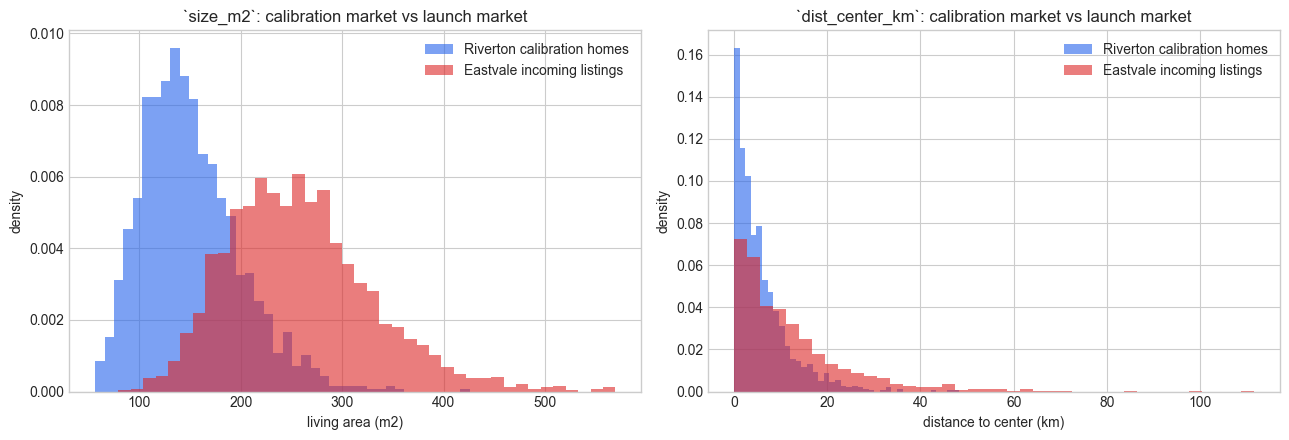

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
panels = [(0, "size_m2", "living area (m2)"), (2, "dist_center_km", "distance to center (km)")]
for ax, (col, name, label) in zip(axes, panels):
    ax.hist(X_calib[:, col], bins=40, density=True, color=BLUE, alpha=0.6,
            label="Riverton calibration homes")
    ax.hist(X_east[:, col], bins=40, density=True, color=RED, alpha=0.6,
            label="Eastvale incoming listings")
    ax.set_title(f"`{name}`: calibration market vs launch market")
    ax.set_xlabel(label)
    ax.set_ylabel("density")
    ax.legend()
plt.tight_layout()
plt.show()

The shift is not subtle once you look: the red `size_m2` histogram sits well to the right
of the blue one, and the red `dist_center_km` distribution has a tail the calibration
market barely samples. Everything in this figure was computed from features only — no
Eastvale prices, no waiting for sales to close. Comparing feature distributions between
the calibration set and incoming production traffic is the cheapest exchangeability audit
there is, and it should run before anyone quotes the guarantee in a new market (field
guide §6).

One caution: histograms prove the mix changed, not how much coverage you lost. A shift in
a feature the noise ignores costs you nearly nothing; a shift into the noisy region costs
you 22 points. To know which one you have, you need the mechanism.

## 3. Why: the mechanism, not magic

Coverage did not rot because the ritual displeased the statistics gods. The mechanism is
concrete, and in our case it has two compounding parts.

Part one is in the simulator's docstring: noise is larger for bigger homes. Two 60 m2
flats sell for nearly the same price; two 300 m2 villas do not. So the honest "typical
error" for a big, far-out home is intrinsically larger than for the median Riverton home.
Part two is the model itself: the gradient boosting machine was trained on Riverton, where
300+ m2 homes are rare, so its predictions are also worst exactly there — trees cannot
extrapolate beyond the data they grew on. Eastvale over-samples precisely the homes where
both the world and the model are at their noisiest.

`q_hat` was set to beat 90% of *calibration* scores — drawn overwhelmingly from small,
close-in, quiet-noise Riverton homes. Eastvale asks that yardstick to cover a population
living in the loud tail. One sentence of theory worth keeping (it is the paper's own
caveat): if the noise were uniform across the feature space, shifting the features would
barely move the score distribution and coverage would barely budge — covariate shift bites
*through* heteroskedasticity, or more generally through any x-dependence of the errors.

mean |residual| on calibration (riverton): 121.0 thousand dollars
mean |residual| on eastvale listings:      245.5 thousand dollars
eastvale homes larger than the largest calibration home: 2.4%


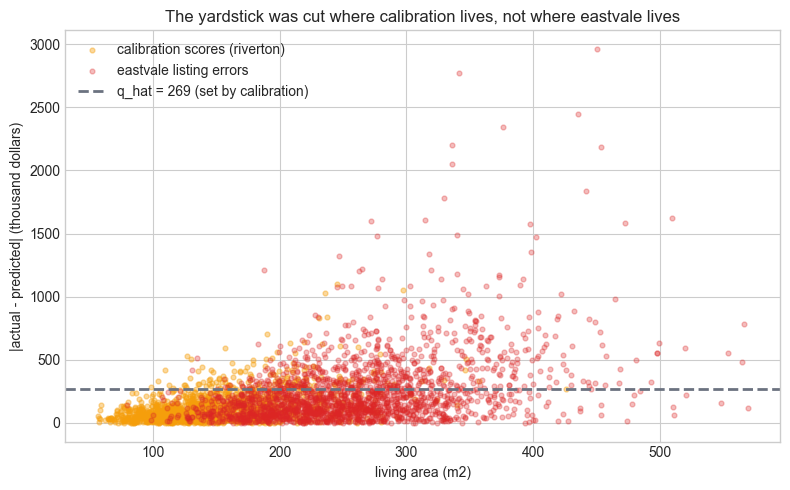

In [6]:
resid_east = np.abs(y_east - pred_east)

print(f"mean |residual| on calibration (riverton): {scores.mean():.1f} thousand dollars")
print(f"mean |residual| on eastvale listings:      {resid_east.mean():.1f} thousand dollars")
print(f"eastvale homes larger than the largest calibration home: "
      f"{np.mean(X_east[:, 0] > X_calib[:, 0].max()):.1%}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_calib[:, 0], scores, s=12, alpha=0.4, color=AMBER,
           label="calibration scores (riverton)")
ax.scatter(X_east[:, 0], resid_east, s=12, alpha=0.3, color=RED,
           label="eastvale listing errors")
ax.axhline(q_hat, color=GRAY, ls="--", lw=2,
           label=f"q_hat = {q_hat:.0f} (set by calibration)")
ax.set_title("The yardstick was cut where calibration lives, not where eastvale lives")
ax.set_xlabel("living area (m2)")
ax.set_ylabel("|actual - predicted| (thousand dollars)")
ax.legend()
plt.tight_layout()
plt.show()

The amber cloud (calibration) is dense on the left, where errors sit mostly below the gray
`q_hat` line — that is why 90% of calibration scores clear it. The red cloud (Eastvale)
lives to the right, where the funnel of errors has opened far above the line. Numerically,
the mean absolute error is 121 thousand dollars on calibration homes and 245.5 on Eastvale
listings — double — and 2.4% of Eastvale homes are larger than *any* home the calibration
set ever saw. Exchangeability between calibration and test is not vaguely "violated"; it
is broken in a specific, measurable direction: the test population over-weights the
right-hand side of this plot.

That specificity is the good news. The failure is not "the world changed, all bets are
off". It is "the world changed *in a way we can point to on the x-axis*". A failure you
can point at, you can reweight.

## 4. The repair idea: reweigh the leaderboard

Plain words first. `q_hat` is a poll of the calibration homes: "what error is big enough
that only 10% of you exceed it?" The poll is broken because the electorate (Riverton
homes) no longer resembles the population being governed (Eastvale listings). The repair
is not to re-run the poll — we have no Eastvale labels — but to *reweight the votes*:
calibration homes that look like Eastvale listings (big, new, far out) should count more
when we pick the quantile; homes unlike Eastvale (small, old, central) should count less.

How much more is not a matter of taste. Each calibration home gets weight equal to the
**likelihood ratio** — how many times more likely its features are to show up on the
Eastvale market than on the Riverton market:

$$w(x) \;=\; \frac{p_{\text{east}}(x)}{p_{\text{riverton}}(x)}$$

where $p_{\text{east}}$ and $p_{\text{riverton}}$ are the two markets' feature densities
and $x$ is one home's feature vector. A home with $w(x) = 3$ is three times more common in
Eastvale than in Riverton, so its score gets three votes. Then we take a *weighted*
corrected quantile: each calibration score $s_i$ carries vote share

$$p_i \;=\; \frac{w(x_i)}{\sum_{j=1}^{n} w(x_j) + w(x_{\text{test}})},$$

the test home reserves its own share $p_{\infty} = w(x_{\text{test}}) \big/ \bigl(\sum_j
w(x_j) + w(x_{\text{test}})\bigr)$ on a phantom score at $+\infty$ (the reserved seat for
the one score we cannot observe — notebook 02's $n+1$ correction, reweighted), and
$\hat{q}(x_{\text{test}})$ is the smallest score where the accumulated vote share reaches
$1 - \alpha$. Here $n$ is the number of calibration homes, $x_i$ their features, and
$\alpha$ the error budget (0.10 throughout).

Why does this restore the guarantee? Recall notebook 03's leaderboard: with exchangeable
data, the newcomer is equally likely to finish at any of the $n+1$ ranks, so it beats the
corrected quantile at most 10% of the time. Under covariate shift the newcomer is no
longer an equal contestant — it is drawn from the big-noisy-home end and tends to finish
near the top. The weights restore the accounting: score by score, they raise each
calibration home's probability of "being the one at that rank" to exactly what it would be
if the home had been drawn from the Eastvale market. Tibshirani et al. call the resulting
symmetry **weighted exchangeability** and prove the repaired guarantee under it — we will
use the theorem, not re-derive it (notebook 03 carries the unweighted version if you want
the flavor of the proof).

The catch, of course, is that $w(x)$ is a ratio of two densities we do not know. The next
section gets it from a tool you already have.

## 5. Your shift detector is your correction factor

Suppose you wanted merely to *detect* the shift: a natural move is to train a classifier
to distinguish calibration rows (label 0) from incoming Eastvale rows (label 1). If it
cannot beat coin-flipping, the markets look alike; if it separates them easily, you have a
shift. Here is the trick that makes this notebook worth its runtime: that detector *is*
the correction factor. By Bayes' rule, the odds a classifier assigns to "this row is
Eastvale" are proportional to the density ratio:

$$\frac{\hat{p}(x)}{1 - \hat{p}(x)} \;\propto\; \frac{p_{\text{east}}(x)}{p_{\text{riverton}}(x)}$$

where $\hat{p}(x)$ is the classifier's predicted probability that a home with features
$x$ came from the Eastvale batch. The proportionality constant is the ratio of batch
sizes — and we do not care, because the vote shares $p_i$ divide by the sum of all
weights, so any constant multiplying $w$ cancels. Knowing the likelihood ratio *up to a
constant* is all weighted conformal needs, and that is exactly what a probabilistic
classifier estimates. Note what this requires from Eastvale: features only. No prices, no
labels, no waiting.

We use a plain logistic regression — the paper found simple, well-specified weight models
give steadier results than flexible ones (their random-forest weights were noticeably
more erratic than logistic ones).

calibration weights: min 0.0003, median 0.071, max 165.1
share of total weight held by the heaviest 5% of calibration homes: 78.6%
effective sample size n_eff = 52   (raw n = 1500)


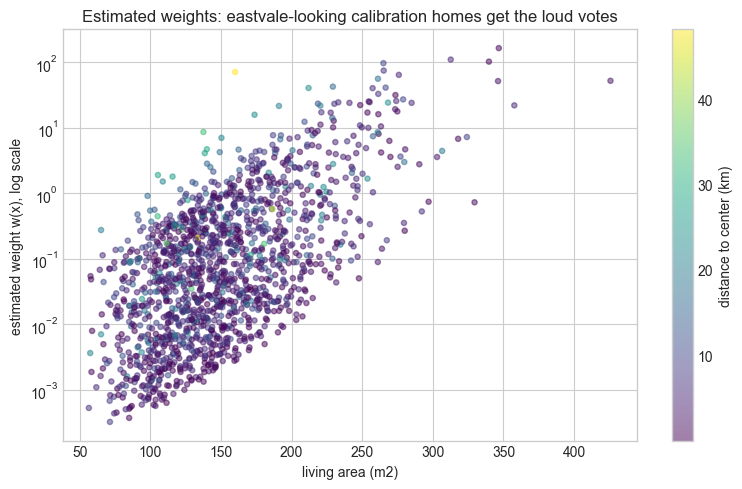

In [7]:
# Label 0 = calibration (riverton), label 1 = incoming eastvale listings.
X_pool = np.vstack([X_calib, X_east])
market = np.concatenate([np.zeros(len(X_calib)), np.ones(len(X_east))])

shift_clf = LogisticRegression(max_iter=5000)
shift_clf.fit(X_pool, market)

p_calib = shift_clf.predict_proba(X_calib)[:, 1]
w_calib = p_calib / (1 - p_calib)          # estimated likelihood ratio, up to a constant
p_east = shift_clf.predict_proba(X_east)[:, 1]
w_east = p_east / (1 - p_east)             # each test home's own weight, for later

# Field guide S11: weighting shrinks the calibration set. Always print n_eff next to n.
n_eff = w_calib.sum() ** 2 / (w_calib ** 2).sum()
top_5pct_share = np.sort(w_calib)[::-1][: int(0.05 * n)].sum() / w_calib.sum()

print(f"calibration weights: min {w_calib.min():.4f}, median {np.median(w_calib):.3f}, max {w_calib.max():.1f}")
print(f"share of total weight held by the heaviest 5% of calibration homes: {top_5pct_share:.1%}")
print(f"effective sample size n_eff = {n_eff:.0f}   (raw n = {n})")

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(X_calib[:, 0], w_calib, s=14, alpha=0.5, c=X_calib[:, 2],
                cmap="viridis")
ax.set_yscale("log")
ax.set_title("Estimated weights: eastvale-looking calibration homes get the loud votes")
ax.set_xlabel("living area (m2)")
ax.set_ylabel("estimated weight w(x), log scale")
fig.colorbar(sc, ax=ax, label="distance to center (km)")
plt.tight_layout()
plt.show()

The scatter confirms the weights behave as section 3 said they must: they climb steeply
with living area (note the log scale — five orders of magnitude from bottom to top) and,
at any given size, the yellow-green points (far from the center) sit above the dark ones.
Big, far-out calibration homes are the ones that look Eastvale, and they now dominate the
poll.

One printout above deserves a careful reading. The median calibration weight is 0.071
while the maximum is 165 — a ratio of over two thousand — and the heaviest 5% of
calibration homes hold 78.6% of the total voting weight. The result is the number that
should give the desk pause: **effective sample size** $n_{\text{eff}} = (\sum_i w_i)^2 /
\sum_i w_i^2$ comes out to 52. In plain English, 1,500 calibration homes are now doing
the statistical work of about 52 equally-weighted ones, because only the Eastvale-looking
minority carries real weight (field guide §11). And notebook 03 taught us what a
52-point calibration set buys: a coverage lottery. Realized coverage will be right *on
average* but can easily swing several points run to run — with $n_{\text{eff}} \approx
52$, swings of ±0.08 around 0.90 would be routine, by the same two-standard-error
yardstick as section 2's ±0.013 (field guide §4). Weighting is not magic; it is a forced
trade of data for validity.

## 6. The weighted quantile, and the fix in action

The implementation is one different quantile computation — about ten lines. Sort the
calibration scores, accumulate their (unnormalized) weights, and return the first score
where the accumulated weight reaches $1-\alpha$ of the total *including the test home's
own weight* sitting at $+\infty$. If the calibration homes never accumulate that much —
because the test home's own weight is more than an $\alpha$ share of the total — the
honest answer is an infinite interval: Riverton simply has too little weight near that
home to certify anything at 90%.

Because the test home's weight enters the denominator, $\hat{q}$ is computed *per test
point*. That is the honest version from the paper, and at our scale it is cheap.

In [8]:
def weighted_conformal_qhat(scores, w_scores, w_test, alpha):
    """Weighted corrected quantile (Tibshirani et al., 2019).

    Each calibration score votes with weight w_scores[i]; one phantom score at
    +infinity votes with the test home's own weight w_test - the reserved seat
    for the score we cannot observe. Returns the smallest score where the
    cumulative vote share reaches 1 - alpha, or +inf if the calibration set
    never accumulates that much weight (the honest 'I cannot certify this').
    """
    order = np.argsort(scores)
    cum_w = np.cumsum(w_scores[order])
    threshold = (1 - alpha) * (cum_w[-1] + w_test)
    idx = np.searchsorted(cum_w, threshold)
    if idx >= len(scores):
        return np.inf
    return scores[order][idx]

# Sanity check: with every weight equal to 1 this must reproduce ordinary split
# conformal - the ceil((n+1)(1-alpha))-th smallest calibration score.
k = math.ceil((n + 1) * (1 - alpha))
equal_weight_q = weighted_conformal_qhat(scores, np.ones(n), 1.0, alpha)
assert equal_weight_q == np.sort(scores)[k - 1], "equal weights must recover split conformal"
print(f"equal-weight weighted quantile: {equal_weight_q:.1f} = the k-th smallest score, k = {k}")
print(f"(notebook 02's np.quantile idiom gave {q_hat:.1f} - its grid can land one score higher;")
print(" both honor the guarantee, the weighted construction is the theorem's exact order statistic)")

equal-weight weighted quantile: 267.5 = the k-th smallest score, k = 1351
(notebook 02's np.quantile idiom gave 268.5 - its grid can land one score higher;
 both honor the guarantee, the weighted construction is the theorem's exact order statistic)


The sanity check passes: with every vote equal to 1, the weighted machinery returns
267.5 — the $k$-th smallest calibration score with $k = \lceil (n+1)(1-\alpha) \rceil =
1351$, which is ordinary split conformal by definition. Notebook 02's `np.quantile`
idiom reported 268.5 on the same scores because its quantile grid can land one score
above that exact order statistic; both constructions honor the guarantee, one is at most
one seat more conservative. Nothing new has happened yet — that is the point of a sanity
check. The new behavior only appears when the weights differ.

In [9]:
# The fix in action: one honest weighted quantile per incoming eastvale listing.
q_hat_east = np.array(
    [weighted_conformal_qhat(scores, w_calib, w, alpha) for w in w_east]
)

finite = np.isfinite(q_hat_east)
cov_east_weighted = np.mean(resid_east <= q_hat_east)  # an infinite interval always covers

print(f"weighted coverage on eastvale:  {cov_east_weighted:.3f}   (unweighted was {cov_east:.3f}, target 0.90)")
print(f"infinite intervals: {np.sum(~finite)} of {len(q_hat_east)} listings ({np.mean(~finite):.1%})")
print(f"median finite interval width:  {2 * np.median(q_hat_east[finite]):.1f} thousand dollars "
      f"(unweighted width was {2 * q_hat:.1f})")
print(f"coverage among finite intervals only: {np.mean(resid_east[finite] <= q_hat_east[finite]):.3f}")

weighted coverage on eastvale:  0.938   (unweighted was 0.687, target 0.90)
infinite intervals: 368 of 2000 listings (18.4%)
median finite interval width:  1014.8 thousand dollars (unweighted width was 537.0)
coverage among finite intervals only: 0.924


Coverage on Eastvale jumps from 0.687 to 0.938 — the promise is honored again, from
Riverton data alone, without a single Eastvale price label. In the paper's airfoil twin,
weighting lifted coverage from 82.2% back to 90.8% with oracle weights and 91.0% with
classifier-estimated weights; our repair overshoots the target more than theirs did, and
it is worth being precise about why. The weighted guarantee is one-sided: *at least*
90%. Unweighted split conformal also has a matching upper bound (it can overcover by at
most $1/(n+1)$), but the weighted version has no such cap — when a single vote share
$p_i$ or $p_\infty$ is large, the cumulative vote share jumps past $1-\alpha$ in one step
and the quantile overshoots. With weights as skewed as ours, and a logistic model whose
linear form cannot exactly match the true log-ratio (it is estimating a misspecified
shape), 0.938 is validity plus a layer of conservatism, not a bug.

Now the bill. The median interval is 1,015 thousand dollars wide, against 537 for the
unweighted method — the price of asking 52 effective calibration homes to speak for a
whole market. And for 368 listings — 18.4% of the launch — the method returns an
*infinite* interval: those homes are so unlike anything in the calibration set that its
accumulated weight cannot certify a 90% band at all. That is not a crash; it is the
method telling you where its knowledge ends (more in section 7). If we score only the
listings that got finite intervals, coverage happens to hold at 0.924 — reassuring, but
read it as an empirical observation, not a promise. "Got a finite interval" is a
selection on the features, and the theorem guarantees nothing conditional on that
selection; the marginal-vs-conditional caution of field guide §3 applies to this slice
like any other.

Because we built the simulator, we can also run the control experiment the real world
never offers: compute the *true* likelihood ratio from the generator's own densities and
see what estimation error cost us. Only the ratio matters, and only up to a constant, so
every normalizing constant is dropped; homes that are impossible in Eastvale (older than
25 years, smaller than 40 m2) get weight exactly zero.

In [10]:
def oracle_weight(X):
    """True eastvale-to-riverton density ratio, up to a constant, read off the simulator.

    Only size, age and dist shift (condition is drawn identically, so it cancels).
    size: gamma(9, 24) shifted +40 in eastvale vs gamma(6, 20) shifted +30 in riverton;
    age: uniform(0, 25) vs uniform(0, 60) -> a constant ratio where age <= 25, else 0;
    dist: exponential(12) vs exponential(6) -> ratio proportional to exp(d/12).
    """
    size, age, dist = X[:, 0], X[:, 1], X[:, 2]
    w = np.zeros(len(X))
    possible = (size > 40.0) & (age <= 25.0)  # outside this, eastvale density is 0
    s, d = size[possible], dist[possible]
    log_w = (
        8.0 * np.log(s - 40.0) - (s - 40.0) / 24.0   # eastvale size density (log, unnormalized)
        - 5.0 * np.log(s - 30.0) + (s - 30.0) / 20.0  # minus riverton size density
        + d / 12.0                                    # exp(-d/12) / exp(-d/6)
    )
    w[possible] = np.exp(log_w)
    return w

w_calib_oracle = oracle_weight(X_calib)
w_east_oracle = oracle_weight(X_east)
n_eff_oracle = w_calib_oracle.sum() ** 2 / (w_calib_oracle ** 2).sum()

q_hat_oracle = np.array(
    [weighted_conformal_qhat(scores, w_calib_oracle, w, alpha) for w in w_east_oracle]
)
finite_o = np.isfinite(q_hat_oracle)

print(f"calibration homes with oracle weight exactly 0: {np.mean(w_calib_oracle == 0):.1%} "
      f"(age > 25 or size < 40 - impossible in eastvale)")
print(f"oracle n_eff = {n_eff_oracle:.0f}   (estimated weights gave {n_eff:.0f}, raw n = {n})")
print(f"oracle-weighted coverage on eastvale: {np.mean(resid_east <= q_hat_oracle):.3f}")
print(f"infinite intervals with oracle weights: {np.sum(~finite_o)} ({np.mean(~finite_o):.1%})")
print(f"median finite width: {2 * np.median(q_hat_oracle[finite_o]):.1f} thousand dollars")

calibration homes with oracle weight exactly 0: 58.7% (age > 25 or size < 40 - impossible in eastvale)
oracle n_eff = 78   (estimated weights gave 52, raw n = 1500)
oracle-weighted coverage on eastvale: 0.904
infinite intervals with oracle weights: 276 (13.8%)
median finite width: 854.1 thousand dollars


With the true weights, coverage lands at 0.904 — within Monte Carlo noise of the 0.90
target. That is the theorem doing exactly what it promises: under covariate shift with
known weights, the repaired guarantee is *exact*, not approximate. The gap between 0.904
(oracle) and 0.938 (estimated) is the cost of estimating $w$ with a misspecified logistic
model — real, but modest, and on the safe side here. Note the theorem's fine print made
flesh: with estimated weights the coverage statement is no longer a theorem at all, just
a well-behaved approximation; the paper observed the same pattern (91.0% estimated vs
90.8% oracle, both fine).

One more subtlety in the printout: the oracle assigns weight *exactly zero* to 58.7% of
the calibration set — every home older than 25 years, which simply cannot appear on the
Eastvale market. More than half the calibration data is, for this launch, statistically
dead weight. Even the oracle can only get $n_{\text{eff}} = 78$ out of these 1,500 homes,
and it still returns 13.8% infinite intervals. The bottleneck is not the estimator; it is
how little of Riverton actually resembles Eastvale.

## 7. Stress tests

Two honesty checks before we recommend anything to the desk. First, the insurance
question: what does the weighted machinery cost when there is *no* shift? If the answer
were "a lot", we could only ever deploy it after proving a shift exists, which is
backwards. So we aim the whole pipeline at the Riverton holdout: train a shift classifier
on calibration-vs-holdout (two samples from the *same* market), turn its odds into
weights, and recompute coverage. Second, the limits question: what happens at the edge of
the data, where no reweighting can help? That one we answer with numbers we already have.

In [11]:
# Stress test (a): apply the weighted method where nothing shifted.
X_pool_none = np.vstack([X_calib, X_river])
market_none = np.concatenate([np.zeros(len(X_calib)), np.ones(len(X_river))])
noshift_clf = LogisticRegression(max_iter=5000)
noshift_clf.fit(X_pool_none, market_none)

p_cal = noshift_clf.predict_proba(X_calib)[:, 1]
w_calib_none = p_cal / (1 - p_cal)
p_riv = noshift_clf.predict_proba(X_river)[:, 1]
w_river_none = p_riv / (1 - p_riv)

n_eff_none = w_calib_none.sum() ** 2 / (w_calib_none ** 2).sum()
q_hat_river = np.array(
    [weighted_conformal_qhat(scores, w_calib_none, w, alpha) for w in w_river_none]
)

print(f"weights when nothing shifted: min {w_calib_none.min():.2f}, median {np.median(w_calib_none):.2f}, "
      f"max {w_calib_none.max():.2f}")
print(f"n_eff = {n_eff_none:.0f} of {n} - almost nothing lost")
print(f"weighted coverage on riverton holdout: {np.mean(np.abs(y_river - pred_river) <= q_hat_river):.3f} "
      f"(unweighted was {cov_river:.3f})")
print(f"median interval width: {2 * np.median(q_hat_river):.1f} (unweighted was {2 * q_hat:.1f})")

weights when nothing shifted: min 1.08, median 1.33, max 1.47
n_eff = 1498 of 1500 - almost nothing lost
weighted coverage on riverton holdout: 0.911 (unweighted was 0.911)
median interval width: 537.0 (unweighted was 537.0)


The no-shift bill is close to zero. The estimated weights are nearly constant — median
1.33, range 1.08 to 1.47 — and a constant weight changes nothing, because constants
cancel in the vote shares. (That median is no accident: with no real signal, the
classifier's odds collapse to the batch-size ratio 2000/1500 ≈ 1.33 — precisely the
constant that cancels.) So $n_{\text{eff}}$ stays at 1,498 of 1,500, coverage is 0.911
weighted versus 0.911 unweighted, and the median width is unchanged at 537. Weighted
conformal degrades gracefully into ordinary conformal when the world has not moved:
near-free insurance. The paper's one caveat applies: an *estimated* weight function
wiggles around the constant it should be, adding a little variance for nothing — which is
why they (and we) prefer a rigid logistic model over a flexible forest for this job.

One trap remains, and it is the absolute limit of the method. The weights let Riverton
data speak *for the part of Eastvale that Riverton plausibly contains*. They cannot
manufacture knowledge where Riverton has literally nothing to say: if Eastvale listed
homes in feature regions Riverton *never* produces (probability zero, not merely rare),
the likelihood ratio would not even be defined there — the theory's absolute-continuity
requirement — and no reweighting of any kind could save you. You cannot calibrate on data
you do not have. Our launch sits just inside that cliff: the far tail of Eastvale is
*possible* in Riverton but vanishingly rare, so instead of undefined weights we get the
18.4% infinite intervals of section 6 — the method's honest signal that for those homes
the calibration set might as well be empty. Treat an infinite (or absurdly wide) interval
as a routing instruction, not a bug: send the home to a human appraiser, and start
collecting labeled sales where the test distribution actually lives (field guide §7 and
§11).

## 8. What this does not fix

Weighted conformal repairs exactly one failure: a shift in *which inputs arrive*, under
an unchanged input-to-output rule. Keep the boundaries in view:

- **Concept drift.** If P(price | features) itself moved — a new property tax, a mortgage
  shock, buyers suddenly paying premiums for home offices — then old scores describe a
  pricing rule that no longer exists, and no reweighting of them can say anything about
  the new one. New data and a retrain are the only fix (field guide §10). Before you
  reach for weights, write down the one-sentence argument for why P(y | x) should be
  stable across your shift. For our launch the sentence exists ("the two regions share
  buyers, appraisers and construction stock; only the mix of listings differs" — and the
  simulator makes it exactly true). If you cannot write that sentence, stop.
- **Continuous drift over time.** Markets rarely jump; they slide. The practical
  heuristic is the same machinery with time-decayed weights — recent calibration points
  count more, stale ones fade (a rolling window is the blunt version). Useful, widely
  used, but the clean finite-sample theorem does not come along for free; coverage
  degrades gracefully with the size of the drift rather than being exactly guaranteed.
- **Estimation error in the weights.** With estimated $\hat{w}$ the guarantee is
  approximate (our 0.938 vs the oracle's 0.904). In four dimensions a logistic
  regression does fine; in four hundred, density-ratio estimation is genuinely hard. If
  the shift is driven by a few variables you can name (region, acquisition channel,
  device type), estimate the ratio on that low-dimensional summary instead of the full
  feature vector.
- **The model itself.** The weights repair the *coverage statement*, not the predictions:
  our gradient booster still extrapolates poorly on 400 m2 homes, which is part of why
  the honest intervals are so wide. A model retrained or fine-tuned toward the new
  market earns narrower intervals at the same guarantee (field guide §5).

Notebook 08 shows what the production libraries provide out of the box — MAPIE, for one,
ships the split/CV+/CQR machinery you have met in this series; the weighted variant is
one custom quantile away, and you now know how to write it.

## 9. Common mistakes to avoid

1. **Validating the guarantee only in-distribution.** A green coverage dashboard computed
   on data that looks like calibration proves nothing about the market you are entering.
   Audit coverage (or at least feature distributions) in the deployment population, per
   launch, per segment.
2. **Confusing covariate shift with concept drift.** Weights repair the input mix under a
   fixed P(y | x). Applied after a regime change, weighted conformal still undercovers —
   and now with extra steps. Write the stability sentence of section 8 first (field guide
   §10).
3. **Skipping the n_eff printout.** Coverage restored at $n_{\text{eff}} = 52$ is a very
   different product from coverage restored at $n_{\text{eff}} = 1{,}400$: expect wide
   intervals and run-to-run coverage swings. If $n_{\text{eff}}$ is small, the honest fix
   is calibration data from the new market, not heavier weights (field guide §11).
4. **Trusting weights from an overfit classifier.** A flexible shift model hallucinates
   non-constant weights out of noise even when nothing shifted, adding variance for
   nothing — and its extreme odds can hand one calibration point half the vote. Prefer a
   simple, regularized classifier on the few variables that drive the shift; clip insane
   weights only as a last resort, and say so in the write-up.
5. **"Fixing" the infinite intervals.** Capping them at some large number quietly
   converts an honest "I cannot certify this home" into a false 90% claim — the exact sin
   conformal prediction was hired to end. Route those homes to a human instead (field
   guide §7).
6. **Forgetting the phantom $+\infty$ vote.** Taking the weighted quantile of the
   calibration scores alone, without the test home's own weight in the denominator, drops
   the $n+1$ correction and undercovers — the weighted version of the off-by-one trap
   (field guide §1).

## 10. What to say in the business review

**Strong version**

> If we launch Eastvale on the Riverton system unchanged, the "90%" price bands will
> cover roughly two offers in three — 68.7% in our launch simulation — and nothing in the
> pipeline will alert us until Eastvale sales close. Reweighting the calibration data
> against the incoming listing mix restores the guarantee using data we already own:
> simulated coverage 93.8%, no Eastvale labels required. The costs are real: the median
> band widens from ±269k to ±507k, and for 18% of Eastvale listings Riverton data cannot
> certify any finite band — those need a human appraiser. Our 1,500 calibration homes do
> the statistical work of about 52 under this shift, so we recommend launching with
> reweighted bands plus human routing, and funding a labeled Eastvale calibration sample
> in the first quarter to earn the narrow bands back.

**Weak version**

> The intervals carry a distribution-free 90% guarantee, and we verified coverage at 91%
> before shipping, so Eastvale is covered by the same guarantee.

The weak version is not lying about any single number; it is quoting a guarantee whose
one load-bearing assumption the launch itself removes. The strong version names the
assumption, prices the repair, and asks for the data that makes the repair temporary.

### The one-line summary

Split conformal's promise is conditional on the world staying shuffled; an expansion
un-shuffles it, silently, and the dashboards will not tell you. But if you can *name*
what changed — which homes arrive, not what they are worth — then a classifier's odds
estimate the likelihood ratio, a weighted quantile restores the promise from data you
already own, and the price appears as wider intervals and a shrunken effective sample
size. Validity can be repaired in place; sharpness must be earned with local data.

The guarantee never breaks loudly — check the world before you quote the number.